# Predicted-target dataset explorer

Loads the predicted-target dataset built by `predicted_dataset_setup.py`
(target = model prediction, scaled to `[0, 1]`) and plots the target and
feature distributions. Run `predicted_dataset_setup.py` first.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'explainit').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from explainit.experiments.continuous_minlp.standard_methods.predicted_dataset_setup import (
    load_predicted_dataset,
)

DATASET = 'diabetes'
data = load_predicted_dataset(DATASET)
feature_names = list(data['feature_names'])
X_train = np.asarray(getattr(data['X_train'], 'values', data['X_train']), dtype=float)
X_test = np.asarray(getattr(data['X_test'], 'values', data['X_test']), dtype=float)
y_train = np.asarray(data['y_train'], dtype=float)
y_test = np.asarray(data['y_test'], dtype=float)
print('features:', feature_names)
print('X_train', X_train.shape, 'X_test', X_test.shape)

2026-07-01 11:50:37,846 - DEBUG - tensorflow - Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
2026-07-01 11:50:38,138 - DEBUG - h5py._conv - Creating converter from 7 to 5
2026-07-01 11:50:38,138 - DEBUG - h5py._conv - Creating converter from 5 to 7
2026-07-01 11:50:38,138 - DEBUG - h5py._conv - Creating converter from 7 to 5
2026-07-01 11:50:38,139 - DEBUG - h5py._conv - Creating converter from 5 to 7


features: ['age', 'sex=0', 'sex=1', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X_train (353, 11) X_test (89, 11)


2026-07-01 11:50:41,525 - DEBUG - matplotlib.pyplot - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-07-01 11:50:41,526 - DEBUG - matplotlib.pyplot - Loaded backend module://matplotlib_inline.backend_inline version unknown.


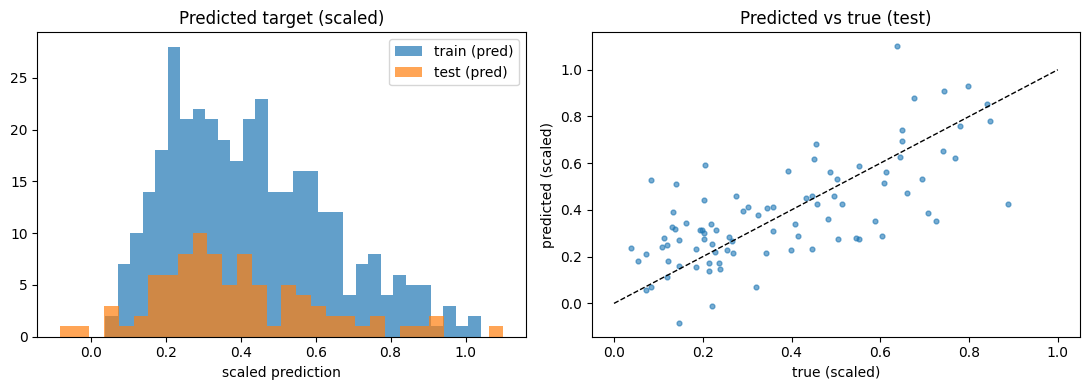

In [2]:
# Predicted-target distribution (scaled) vs. original labels, if available.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(y_train, bins=30, alpha=0.7, label='train (pred)')
ax[0].hist(y_test, bins=30, alpha=0.7, label='test (pred)')
ax[0].set_title('Predicted target (scaled)')
ax[0].set_xlabel('scaled prediction'); ax[0].legend()

if 'y_test_true' in data:
    ax[1].scatter(np.asarray(data['y_test_true'], dtype=float), y_test, s=12, alpha=0.6)
    lims = [0, 1]
    ax[1].plot(lims, lims, 'k--', lw=1)
    ax[1].set_xlabel('true (scaled)'); ax[1].set_ylabel('predicted (scaled)')
    ax[1].set_title('Predicted vs true (test)')
plt.tight_layout(); plt.show()

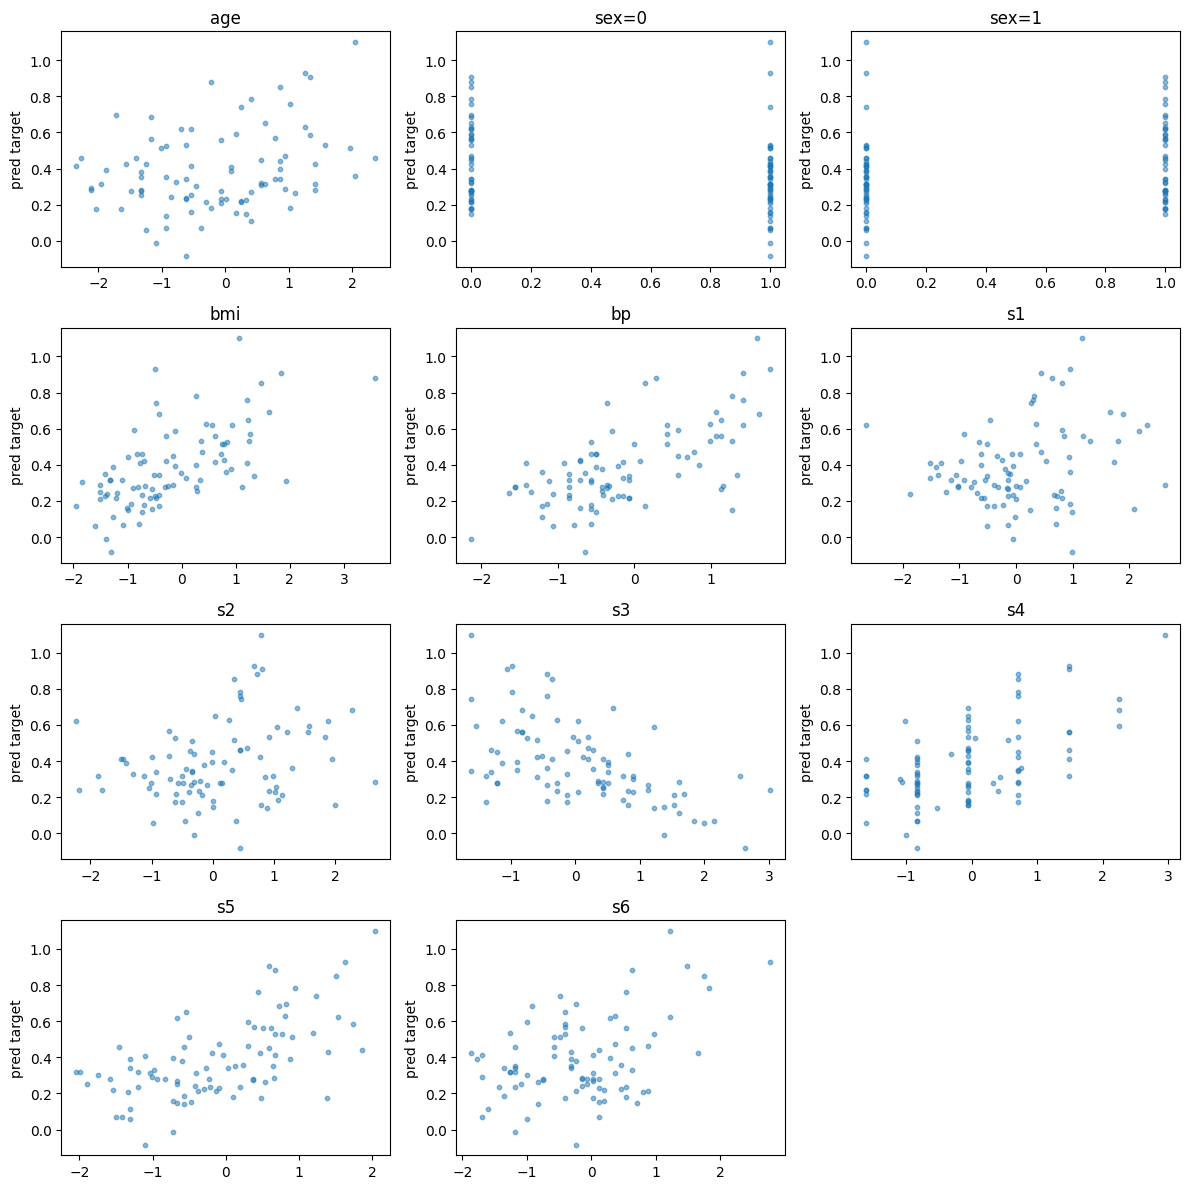

In [3]:
# Feature vs predicted target scatter (test set).
n = len(feature_names)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
axes = np.atleast_1d(axes).ravel()
for i, name in enumerate(feature_names):
    axes[i].scatter(X_test[:, i], y_test, s=10, alpha=0.5)
    axes[i].set_title(name); axes[i].set_ylabel('pred target')
for j in range(n, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()